1. Plot images from the training set in a  2×5  grid.

In [41]:
!pip install --upgrade datasets einops diffusers

In [42]:
from datasets import load_dataset
from torchvision.transforms import (CenterCrop,
    Compose,InterpolationMode,RandomHorizontalFlip,
    Resize,ToTensor)

resolution=64

augmentations = Compose([
    Resize(resolution,
    interpolation=InterpolationMode.BILINEAR),
    CenterCrop(resolution),
    RandomHorizontalFlip(),
    ToTensor(),])    #Defines several image augmentation methods

def transforms(examples):
    images = [augmentations(image.convert("RGB"))
        for image in examples["image"]]
    return {"input": images}

dataset = load_dataset("huggan/flowers-102-categories",
    split="train",)    #Downloads the data from Hugging Face directly
dataset.set_transform(transforms)    #Performs image transformations

In [43]:
import torch

torch.manual_seed(42)
batch_size=2#aici-------------------------------------------------------------------------------------pt a avea 2 x 5
train_dataloader=torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

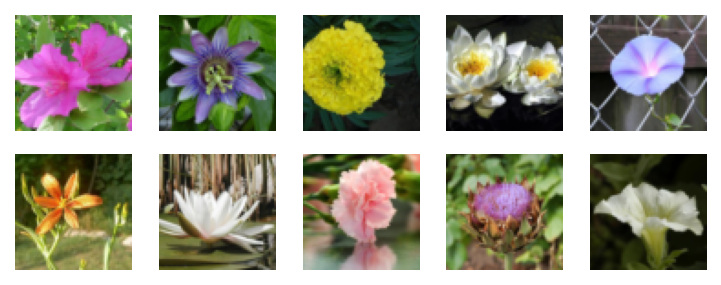

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.9,batch_size),dpi=150)
for col in range(5):    #aici---------------------------------------------------------------------------------------
    imgs=next(iter(train_dataloader))["input"]
    for row in range(batch_size):
        plt.subplot(batch_size,6,col+1+row*6)
        img=imgs[row].permute(1,2,0)    #Changes from channel first to channel last
        plt.imshow(torch.clip(img,0,1))    #Clips image values so they fall in the range [0, 1]
        plt.axis('off')
plt.tight_layout()
plt.show()

2. Modify the code for applying forward diffusion to flower images. Use four images from the training set to generate images in time steps  0 ,  250 ,  500 ,  750 , and  1,000 . Plot them in a  4×5  grid.

In [45]:
import torch

torch.manual_seed(42)
batch_size=4
train_dataloader=torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True)

In [46]:
import math
from typing import Union

import numpy as np
from tqdm import tqdm


def normalize_to_neg_one_to_one(img):
    return img * 2 - 1


def unnormalize_to_zero_to_one(t):
    return (t + 1) * 0.5


def match_shape(values, broadcast_array, tensor_format="pt"):
    values = values.flatten()

    while len(values.shape) < len(broadcast_array.shape):
        values = values[..., None]
    if tensor_format == "pt":
        values = values.to(broadcast_array.device)

    return values


def clip(tensor, min_value=None, max_value=None):
    if isinstance(tensor, np.ndarray):
        return np.clip(tensor, min_value, max_value)
    elif isinstance(tensor, torch.Tensor):
        return torch.clamp(tensor, min_value, max_value)

    raise ValueError("Tensor format is not valid is not valid - " \
        f"should be numpy array or torch tensor. Got {type(tensor)}.")


def cosine_beta_schedule(timesteps, beta_start, beta_end, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, beta_start, beta_end)


class DDIMScheduler:
    def __init__(
        self,
        num_train_timesteps=1000,
        beta_start=0.0001,
        beta_end=0.02,
        beta_schedule="cosine",
        clip_sample=True,
        set_alpha_to_one=True
    ):

        if beta_schedule == "linear":
            self.betas = np.linspace(beta_start, beta_end, num_train_timesteps, dtype=np.float32)
        elif beta_schedule == "cosine":
            self.betas = cosine_beta_schedule(num_train_timesteps,
                                              beta_start=beta_start,
                                              beta_end=beta_end)
        else:
            raise NotImplementedError(
                f"{beta_schedule} does is not implemented for {self.__class__}")

        self.num_train_timesteps = num_train_timesteps
        self.clip_sample = clip_sample
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.final_alpha_cumprod = np.array(1.0) if set_alpha_to_one else self.alphas_cumprod[0]

        self.num_inference_steps = None
        self.timesteps = np.arange(0, num_train_timesteps)[::-1].copy()

    def _get_variance(self, timestep, prev_timestep):
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)

        return variance

    def set_timesteps(self, num_inference_steps, offset=0):
        self.num_inference_steps = num_inference_steps
        self.timesteps = np.arange(0, 1000, 1000 // num_inference_steps)[::-1].copy()
        self.timesteps += offset

    def step(
        self,
        model_output: Union[torch.FloatTensor, np.ndarray],
        timestep: int,
        sample: Union[torch.FloatTensor, np.ndarray],
        eta: float = 1.0,
        use_clipped_model_output: bool = True,
        generator=None,
    ):
        # 1. get previous step value (=t-1)
        prev_timestep = timestep - self.num_train_timesteps // self.num_inference_steps

        # 2. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[
            prev_timestep] if prev_timestep >= 0 else self.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t

        # 3. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        pred_original_sample = (sample - beta_prod_t**(0.5) * model_output) / alpha_prod_t**(0.5)

        # 4. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = clip(pred_original_sample, -1, 1)

        # 5. compute variance: "sigma_t(η)" -> see formula (16)
        # σ_t = sqrt((1 − α_t−1)/(1 − α_t)) * sqrt(1 − α_t/α_t−1)
        variance = self._get_variance(timestep, prev_timestep)
        std_dev_t = eta * variance**(0.5)

        if use_clipped_model_output:
            # the model_output is always re-derived from the clipped x_0 in Glide
            model_output = (sample -
                            alpha_prod_t**(0.5) * pred_original_sample) / beta_prod_t**(0.5)

        # 6. compute "direction pointing to x_t" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        pred_sample_direction = (1 - alpha_prod_t_prev - std_dev_t**2)**(0.5) * model_output

        # 7. compute x_t without "random noise" of formula (12) from https://arxiv.org/pdf/2010.02502.pdf
        prev_sample = alpha_prod_t_prev**(0.5) * pred_original_sample + pred_sample_direction

        if eta > 0:
            device = model_output.device if torch.is_tensor(model_output) else "cpu"
            noise = torch.randn(model_output.shape, generator=generator).to(device)
            variance = self._get_variance(timestep, prev_timestep)**(0.5) * eta * noise

            if not torch.is_tensor(model_output):
                variance = variance.numpy()

            prev_sample = prev_sample + variance

        return prev_sample

    def add_noise(self, original_samples, noise, timesteps):
        timesteps = timesteps.cpu()
        sqrt_alpha_prod = self.alphas_cumprod[timesteps]**0.5
        sqrt_alpha_prod = match_shape(sqrt_alpha_prod, original_samples)
        sqrt_one_minus_alpha_prod = (1 - self.alphas_cumprod[timesteps])**0.5
        sqrt_one_minus_alpha_prod = match_shape(sqrt_one_minus_alpha_prod, original_samples)

        noisy_samples = sqrt_alpha_prod * original_samples + sqrt_one_minus_alpha_prod * noise
        return noisy_samples

    @torch.no_grad()
    def generate(self,model,device,batch_size=1,generator=None,
         eta=1.0,use_clipped_model_output=True,num_inference_steps=50):
        # Create a list to store intermediate images
        imgs=[]
        # Generate the initial random noise tensor
        image=torch.randn((batch_size,model.in_channels,model.sample_size,
            model.sample_size),generator=generator).to(device)
        self.set_timesteps(num_inference_steps)
        # Iteratively denoise the image using the trained U-Net model
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
                  use_clipped_model_output=use_clipped_model_output)
            img = unnormalize_to_zero_to_one(image)
            img = img.cpu().permute(0, 2, 3, 1).numpy()
            imgs.append(img)
        # Output the final clean image and the intermediate noisy images
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return image, imgs

    @torch.no_grad()
    def interpolate(self,model,a_idx,b_idx,batch_size=1,generator=None,
        eta=1.0,use_clipped_model_output=True,num_inference_steps=50,
                 device=None):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        image0 = torch.randn((batch_size, model.in_channels,
          model.sample_size, model.sample_size),generator=generator,
                             ).to(device)
        image = torch.zeros((batch_size, model.in_channels,
          model.sample_size, model.sample_size)).to(device)
        # Pick two initial noise tensors
        a,b=image0[a_idx],image0[b_idx]
        # Create 10 interpolated noise tensors by placing different weights on the 2 noise tensors
        for i in range(10):
            ab=torch.sin(torch.tensor(0.5*math.pi*(0.05+i/10)))*a+\
                torch.cos(torch.tensor(0.5*math.pi*(0.05+i/10)))*b
            image[i]=ab
        self.set_timesteps(num_inference_steps)
        # Generate images by iteratively denoising the interpolated noise tensors
        for t in tqdm(self.timesteps):
            model_output = model(image, t)["sample"]
            image = self.step(model_output,t,image,eta,
              use_clipped_model_output=use_clipped_model_output,
                              generator=generator)
        image = unnormalize_to_zero_to_one(image)
        image = image.cpu().permute(0, 2, 3, 1).numpy()
        return image

    def __len__(self):
        return self.num_train_timesteps

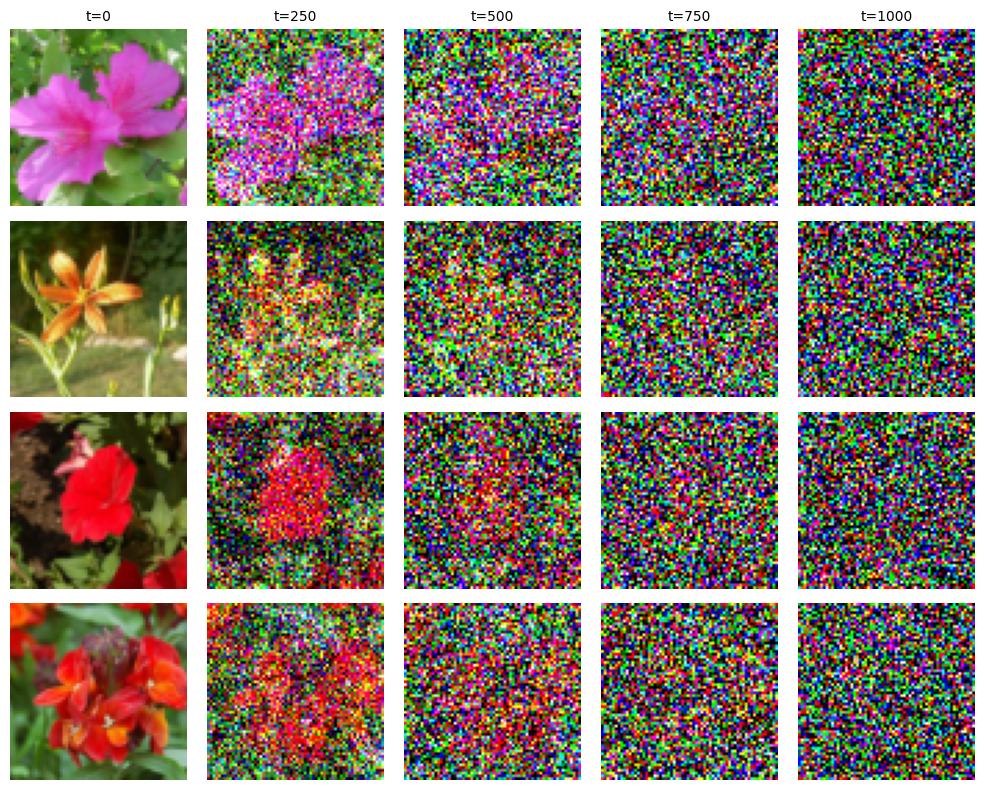

In [47]:
import torch
import matplotlib.pyplot as plt

noise_scheduler = DDIMScheduler(num_train_timesteps=1000)

# Get 4 clean flower images  →  shape: (4, 3, 64, 64)
batch = next(iter(train_dataloader))["input"]
imgs = batch.permute(0, 2, 3, 1)                # (4, 64, 64, 3)  channel-last

timesteps = [0, 250, 500, 750, 1000]            # 5 columns

plt.figure(figsize=(10, 8), dpi=100)
for row in range(4):                            # one row per image
    img = imgs[row]                             # (64, 64, 3)
    for col, t in enumerate(timesteps):         # one col per timestep
        subplot_idx = row * 5 + col + 1         # 1-based index
        plt.subplot(4, 5, subplot_idx)

        if t == 0:
            # t=0: show the original clean image
            noisy = img
        else:
            noisy = noise_scheduler.add_noise(img, torch.randn(img.shape), torch.tensor([t - 1]).long())

        plt.imshow(torch.clip(noisy, 0, 1))
        plt.axis("off")
        if row == 0:
            plt.title(f"t={t}", fontsize=10)    # label columns on top row only
plt.tight_layout()
plt.show()

3. Modify the code for image generation with the trained denoising U-Net, and change the random seed to  42 . Keep the rest of the code the same. Rerun the code to see what the generated images look like.

In [48]:
def sinusoidal_embedding(timesteps, dim):
    half_dim = dim // 2
    exponent = -math.log(10000) * torch.arange(
        start=0, end=half_dim, dtype=torch.float32)
    exponent = exponent / (half_dim - 1.0)
    emb = torch.exp(exponent).to(device=timesteps.device)
    emb = timesteps[:, None].float() * emb[None, :]
    return torch.cat([emb.sin(), emb.cos()], dim=-1) #In fixed positional encoding, the sine function applies to even positions and the cosine function to odd positions.

In [49]:
from torch import nn, einsum

from einops import rearrange

class Attention(nn.Module):

    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, 'b (h c) x y -> b h c (x y)', h=self.heads),
            qkv)

        q = q * self.scale

        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        attn = sim.softmax(dim=-1)
        out = einsum('b h i j, b h d j -> b h i d', attn, v)

        out = rearrange(out, 'b h (x y) d -> b (h d) x y', x=h, y=w)
        return self.to_out(out)

In [50]:
from torch.nn import functional as F
from einops.layers.torch import Rearrange


def get_downsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2),
            nn.Conv2d(in_dim * 4, hidden_dim, 1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


def get_attn_layer(in_dim, is_last):
    if is_last:
        return Residual(PreNorm(in_dim, Attention(in_dim)))
    else:
        return nn.Identity()


def get_upsample_layer(in_dim, hidden_dim, is_last):
    if not is_last:
        return nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'),
                             nn.Conv2d(in_dim, hidden_dim, 3, padding=1))
    else:
        return nn.Conv2d(in_dim, hidden_dim, 3, padding=1)


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


class LayerNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.g = nn.Parameter(torch.ones(1, dim, 1, 1))

    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        var = torch.var(x, dim=1, unbiased=False, keepdim=True)
        mean = torch.mean(x, dim=1, keepdim=True)
        return (x - mean) * (var + eps).rsqrt() * self.g


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class ResidualBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 temb_channels,
                 kernel_size=3,
                 stride=1,
                 padding=1,
                 groups=8):
        super(ResidualBlock, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.time_emb_proj = nn.Sequential(
            nn.SiLU(), torch.nn.Linear(temb_channels, out_channels))

        self.residual_conv = nn.Conv2d(
            in_channels, out_channels=out_channels,
            kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=stride,
                               padding=padding)

        self.norm1 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.norm2 = nn.GroupNorm(num_channels=out_channels, num_groups=groups)
        self.nonlinearity = nn.SiLU()

    def forward(self, x, temb):
        residual = self.residual_conv(x)

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.nonlinearity(x)

        temb = self.time_emb_proj(self.nonlinearity(temb))
        x += temb[:, :, None, None]

        x = self.conv2(x)
        x = self.norm2(x)
        x = self.nonlinearity(x)

        return x + residual


class UNet(nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_dims=[128, 256, 512, 1024],
                 image_size=64):
        super(UNet, self).__init__()

        self.sample_size = image_size
        self.in_channels = in_channels
        self.hidden_dims = hidden_dims

        timestep_input_dim = hidden_dims[0]
        time_embed_dim = timestep_input_dim * 4

        self.time_embedding = nn.Sequential(
            nn.Linear(timestep_input_dim, time_embed_dim), nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim))

        self.init_conv = nn.Conv2d(in_channels,
                                   out_channels=hidden_dims[0],
                                   kernel_size=3,
                                   stride=1,
                                   padding=1)

        down_blocks = []

        in_dim = hidden_dims[0]
        for idx, hidden_dim in enumerate(hidden_dims[1:]):
            is_last = idx >= (len(hidden_dims) - 2)
            down_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_downsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.down_blocks = nn.ModuleList(down_blocks)

        mid_dim = hidden_dims[-1]
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, time_embed_dim)

        up_blocks = []
        in_dim = mid_dim
        for idx, hidden_dim in enumerate(list(reversed(hidden_dims[:-1]))):
            is_last = idx >= (len(hidden_dims) - 2)
            up_blocks.append(
                nn.ModuleList([
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    ResidualBlock(in_dim + hidden_dim, in_dim, time_embed_dim),
                    get_attn_layer(in_dim, is_last),
                    get_upsample_layer(in_dim, hidden_dim, is_last)
                ]))
            in_dim = hidden_dim

        self.up_blocks = nn.ModuleList(up_blocks)

        self.out_block = ResidualBlock(hidden_dims[0] * 2, hidden_dims[0],
                                       time_embed_dim)
        self.conv_out = nn.Conv2d(hidden_dims[0], out_channels=3, kernel_size=1)

    def forward(self, sample, timesteps):
        if not torch.is_tensor(timesteps):
            timesteps = torch.tensor([timesteps],
                                     dtype=torch.long,
                                     device=sample.device)

        timesteps = torch.flatten(timesteps)
        timesteps = timesteps.broadcast_to(sample.shape[0])

        t_emb = sinusoidal_embedding(timesteps, self.hidden_dims[0])
        t_emb = self.time_embedding(t_emb)

        x = self.init_conv(sample)
        r = x.clone()

        skips = []
        for block1, block2, attn, downsample in self.down_blocks:
            x = block1(x, t_emb)
            skips.append(x)

            x = block2(x, t_emb)
            x = attn(x)
            skips.append(x)

            x = downsample(x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        for block1, block2, attn, upsample in self.up_blocks:
            x = torch.cat((x, skips.pop()), dim=1)
            x = block1(x, t_emb)

            x = torch.cat((x, skips.pop()), dim=1)
            x = block2(x, t_emb)
            x = attn(x)

            x = upsample(x)

        x = self.out_block(torch.cat((x, r), dim=1), t_emb)
        out = self.conv_out(x)
        return {"sample": out}

In [51]:
device="cuda" if torch.cuda.is_available() else "cpu"
resolution=64
model=UNet(3,hidden_dims=[128,256,512,1024],
           image_size=resolution).to(device) #Instantiates the UNet class to create a denoising U-Net model
num=sum(p.numel() for p in model.parameters())
print("number of parameters: %.2fM" % (num/1e6,)) #Counts the number of model parameters

number of parameters: 133.42M


In [52]:
from diffusers.optimization import get_scheduler

optimizer=torch.optim.AdamW(model.parameters(),lr=0.0001,
    betas=(0.95,0.999),weight_decay=0.00001,eps=1e-8)    #Uses the AdamW optimizer
lr_scheduler=get_scheduler(    #Uses the learning rate scheduler from the diffusers library
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=300,
    num_training_steps=(len(train_dataloader) * 100))

 98%|█████████▊| 49/50 [00:16<00:00,  3.14it/s]/tmp/ipykernel_2532/2060487891.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
100%|██████████| 50/50 [00:16<00:00,  3.05it/s]


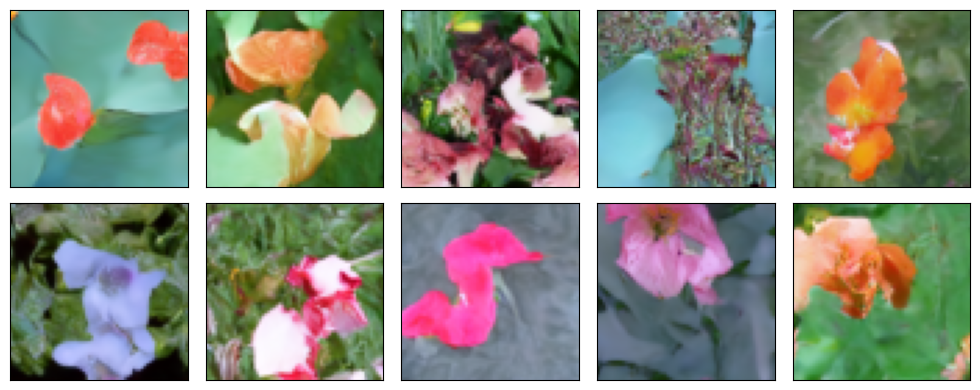

In [55]:
sd=torch.load('files/diffusion.pth',weights_only=True)

model.load_state_dict(sd) #Loads the trained model parameters
with torch.no_grad():
    generator = torch.manual_seed(42)#aici-----------------------------------------------------
    generated_images,imgs = noise_scheduler.generate(
        model,device=device,
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10) #Generates 10 flower images using the trained model
imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10): #Plots the generated images in a 2 × 5 grid
    ax = plt.subplot(2,5, i + 1)
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()

4.   Modify the code for interpolating initial noise tensors to use the third and fourth initial noise tensors to generate $10$
interpolated images. Keep the rest of the code the same (in particular, keep the random
state to $100$). Rerun the code to see what the generated images look like.



 98%|█████████▊| 49/50 [00:15<00:00,  2.98it/s]/tmp/ipykernel_2532/2060487891.py:84: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  variance = (beta_prod_t_prev / beta_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
100%|██████████| 50/50 [00:15<00:00,  3.21it/s]


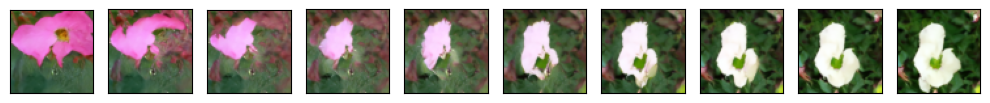

In [73]:
import torch


with torch.no_grad():
    generator = torch.manual_seed(100)
    generated_images = noise_scheduler.interpolate(#aici------------------------------------------------------------------------------------------
        model,
        2,#aici------------------------------------------------------------------------------------------
        3,#aici------------------------------------------------------------------------------------------
        num_inference_steps=50,
        generator=generator,
        eta=0,
        use_clipped_model_output=True,
        batch_size=10) #Generates 10 flower images using the trained model
imgnp=generated_images

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4),dpi=100)
for i in range(10): #grid de 1 x 10
    ax = plt.subplot(1,10, i + 1)#aici------------------------------------------------------------------------------------------
    plt.imshow(imgnp[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
plt.show()